# Extreme Value Analysis

Please refer to the following link for the theory on this topic.

https://tudelft-citg.github.io/HOS-prob-design/intro.html

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import plotly.graph_objects as go
import itertools
from scipy.signal import find_peaks
from matplotlib import pyplot as plt
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

- Establish the Peak Over Threshold values.
- Starting point is Hs data in file hsarras=ys POT test.csv with 3 hour Hs data
- Here the Thershold (thresh) is chosen $H_s = 2.5 m$ and the time is 4 (j) * 3 hrs = 12 hrs
- Peaks delivers the POT values over which one should do the Weibull or Gumbel fit

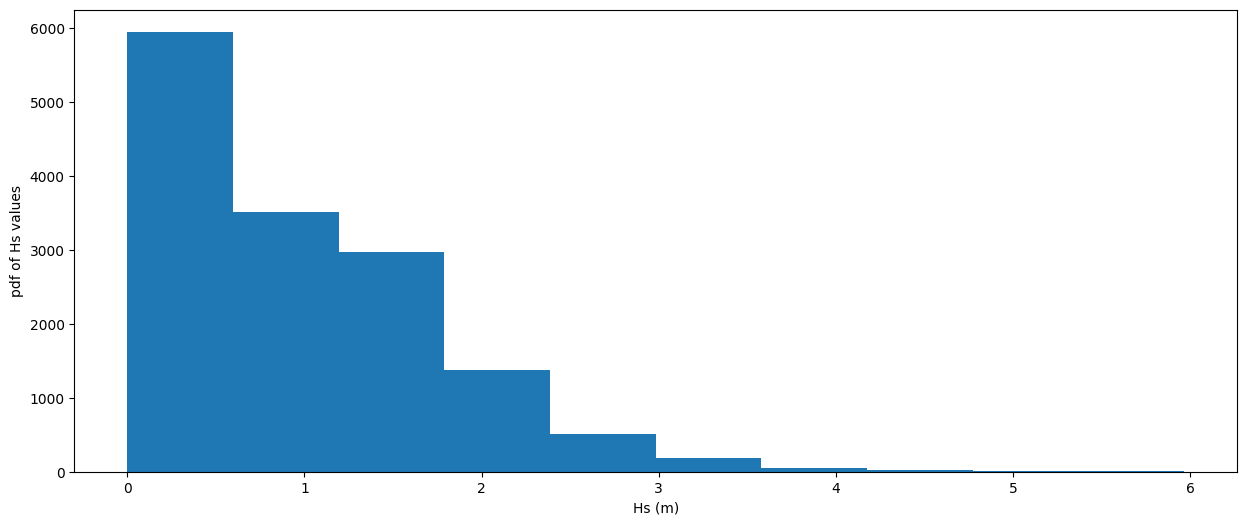

Number of Hs values:  14608



In [2]:
wave_data = pd.read_csv('hsarrays_combined.csv')
time_series = wave_data['Hs']
# 
#  Extract Hs from database and plot histogram
#

fig, ax = plt.subplots(1, 1)
plt.xlabel('Hs (m)')
plt.ylabel('pdf of Hs values')
ax.hist(time_series, histtype='stepfilled')
plt.show()

#
imax = len(time_series)
print('Number of Hs values: ',imax)
print()
dft = wave_data.get("time")
pass

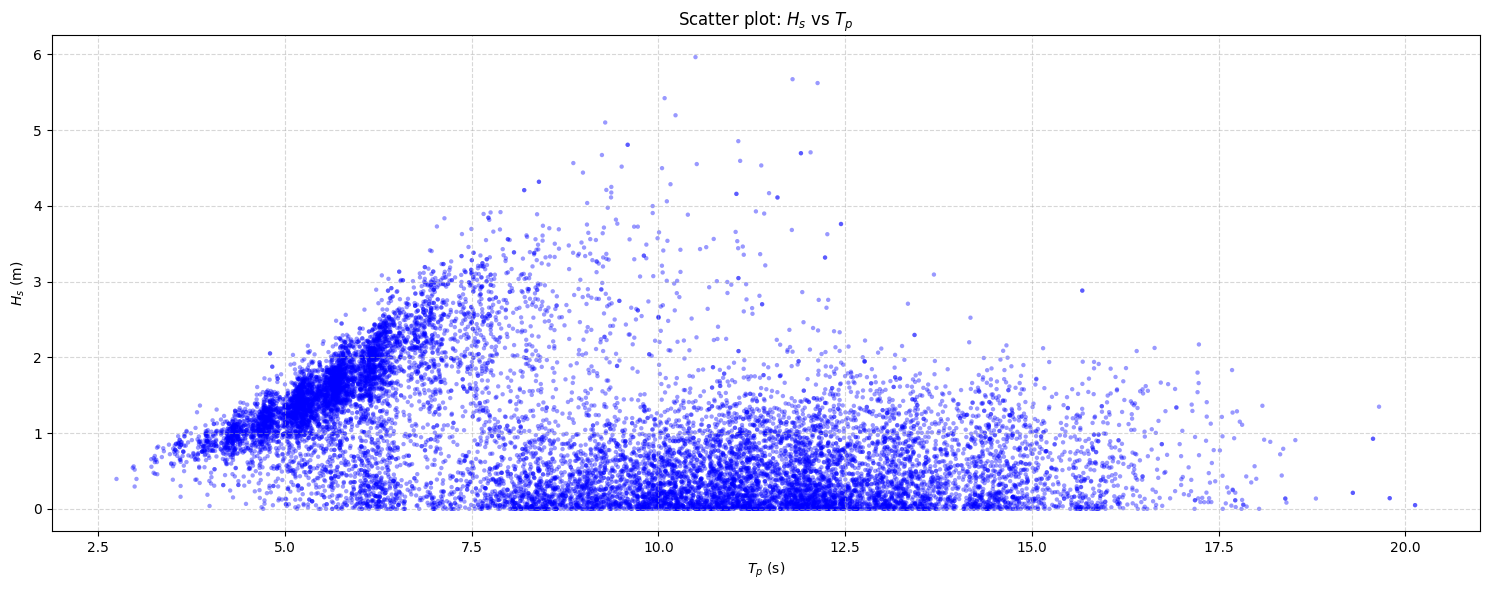

In [3]:
# Scatter plot: Tp (x-axel) vs Hs (y-axel)
fig, ax = plt.subplots(1, 1)

ax.scatter(
    wave_data['Tp'],
    wave_data['Hs'],
    s=10,           # dot size
    alpha=0.4,      # transparency
    color='blue',
    edgecolors='none'
)

ax.set_xlabel('$T_p$ (s)')
ax.set_ylabel('$H_s$ (m)')
ax.set_title('Scatter plot: $H_s$ vs $T_p$')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Peak over threshold

In [4]:
#
# Peak Over Through code
def pot_method(data, threshold, dtime):
    idx_pot, _ = find_peaks(data, height = threshold, distance = dtime)
    pot_list = data.loc[idx_pot]
    return idx_pot, pot_list
#

In [5]:
fig = go.Figure(data=go.Scatter(
    y = time_series,
    mode = 'lines'
))

fig.show()

In [6]:
#
# threshold is the Hs threshold value
# dtime is the number of values used in time (here 4 * 3 hour samples = 12 hrs)
#
threshold = 3.7
dtime = 6
tare = threshold

indices,pot_maxima = pot_method(time_series, threshold, dtime)

kmax = len(pot_maxima)
print("Number of peaks based on Threshold: ",threshold," and time ",dtime," is ",kmax)
print('Last part of the calculated Peaks over Threshold values: ')
print(pot_maxima.tail())

import pandas as pd
import numpy as np

# ============================================================
# EXPORT ONLY Hs POT VALUES TO CSV
# ============================================================

# 1. Convert the pandas Series to a clean numpy array and round to 1 decimal
hs_values = np.round(pot_maxima.values, 1)

# 2. Create a clean DataFrame with only the 'Hs' column
df_only_hs = pd.DataFrame({
    'Hs': hs_values
})

# 3. Save to CSV without row numbers (index=False)
output_filename = "pot_hs_only.csv"
df_only_hs.to_csv(output_filename, index=False)

print("=" * 60)
print(f"SUCCESS: Exported {len(df_only_hs)} POT Hs-values to '{output_filename}'")
print("=" * 60)
print("Preview of the CSV file content:")
print(df_only_hs.head(5).to_string(index=False))

Number of peaks based on Threshold:  3.7  and time  6  is  32
Last part of the calculated Peaks over Threshold values: 
12493    4.855225
12564    4.176758
12678    3.889893
13497    4.552734
14185    3.918213
Name: Hs, dtype: float64
SUCCESS: Exported 32 POT Hs-values to 'pot_hs_only.csv'
Preview of the CSV file content:
 Hs
3.9
4.1
4.2
3.8
3.8


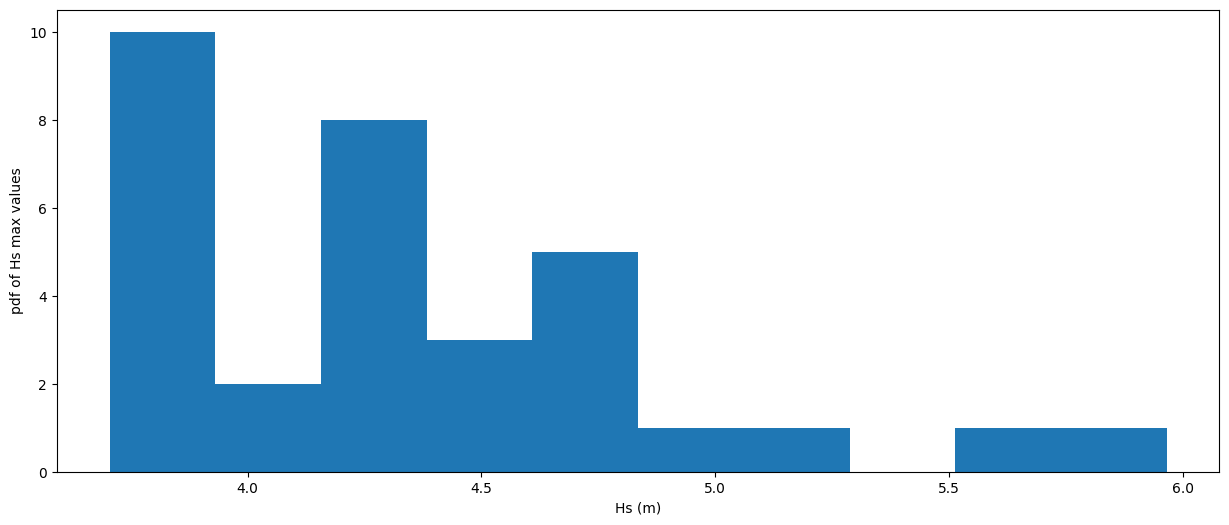

In [ ]:

sub_ind = []
j = 0
for i in range(0,24):
    k = j + i
    val = indices[k]
    sub_ind.append(val)
#
sub_pot = pot_maxima.loc[sub_ind]


inst = sub_ind[0]
inen = sub_ind[23]
sub_tim = time_series[inst:inen]
sub_pos = list(itertools.chain(range(inst, inen)))
#
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sub_pos,y=sub_tim,
    mode='lines',
    name='Original Plot'
))

#
#
fig.add_trace(go.Scatter(
    x=sub_ind,y=sub_pot,
    mode='markers',
    marker=dict(
        size=8,
        color='red',
        symbol='cross'
    ),
    name='Detected Peaks'
))

fig.show()

#
pot_time = []
for i in range(0,kmax):
    val = indices[i]
    pot_time.append(dft[val])
#
fig, ax = plt.subplots(1, 1)
plt.xlabel('Hs (m)')
plt.ylabel('pdf of Hs max values')
ax.hist(pot_maxima, histtype='stepfilled')
plt.show()
#
pass

In [8]:
array = np.array([indices, 
         pot_time,
         pot_maxima])

array = array.T

df = pd.DataFrame(array, columns=['index', 'pot_time', 'pot_maxima'])

df.to_csv('EVA result POT extremes.csv', index=False)


## Extreme value distributions

In [9]:
import reliability.Fitters as rf

Tare the values of wave height against the threshold before fitting the distribution

In [10]:
dfmax = []
for it in pot_maxima.items():
    val = it[1] - tare # pot_maxima[i]
    dfmax.append(val)    
dfmax.sort()

### Fit Weibull 2P

Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 32/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha        0.659597        0.110361   0.47518  0.915585
     Beta          1.1073        0.157363  0.838105   1.46296 

Goodness of fit    Value
 Log-likelihood -17.3133
           AICc  39.0404
            BIC  41.5581
             AD 0.705094 



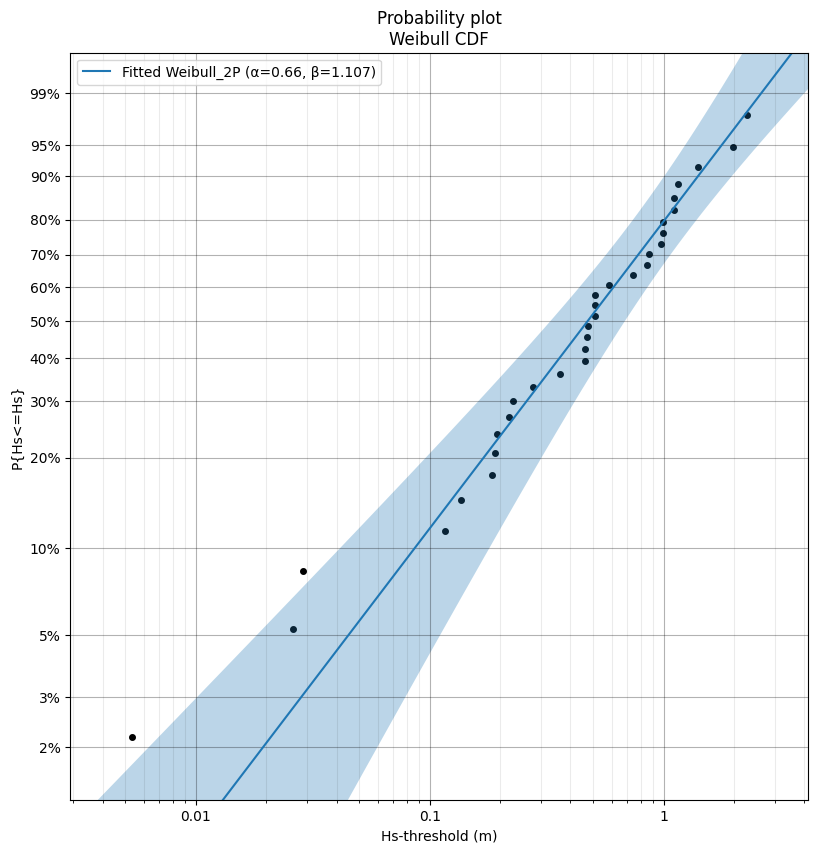

In [11]:
waw2 = rf.Fit_Weibull_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

### Fit Weibull 3P

Results from Fit_Weibull_3P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 32/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha        0.659597        0.110361   0.47518  0.915585
     Beta          1.1073        0.157363  0.838105   1.46296
    Gamma               0               0         0         0 

Goodness of fit    Value
 Log-likelihood -17.3133
           AICc  41.4837
            BIC  45.0238
             AD 0.705094 



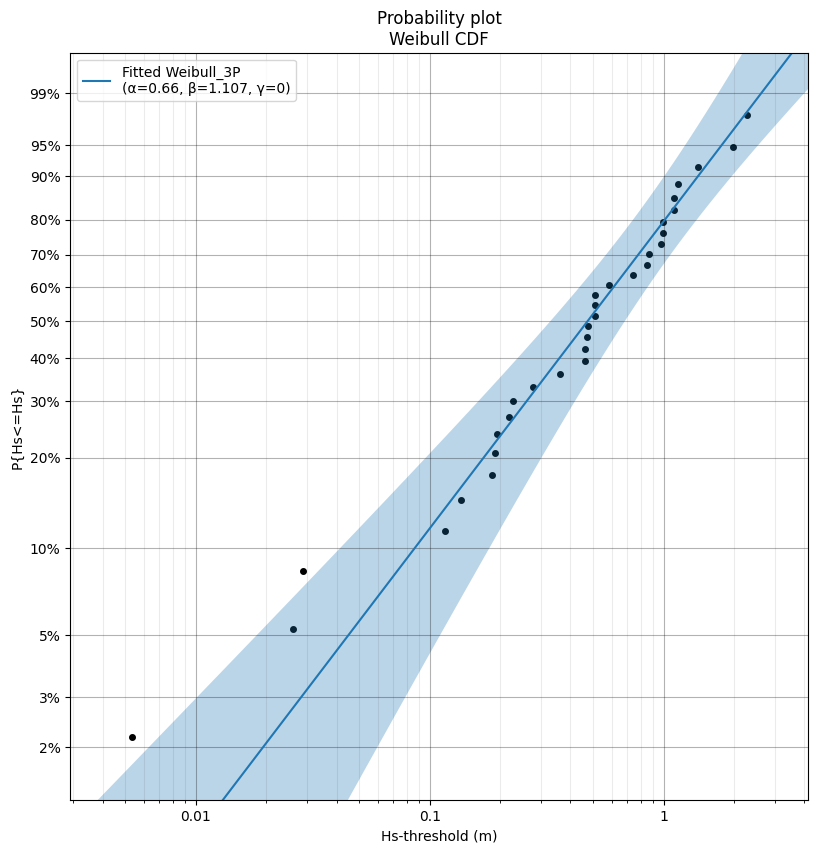

In [12]:
#
#  Weibull 3P fit delivers alpha = scale factor, beta = shape factor & gamma = location factor

waw3 = rf.Fit_Weibull_3P(failures=dfmax)

plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()


### Fit Gumbel 2P

Results from Fit_Gumbel_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 32/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
       Mu        0.932982        0.125301  0.687397   1.17857
    Sigma         0.66478       0.0784065  0.527575  0.837667 

Goodness of fit    Value
 Log-likelihood -33.1917
           AICc  70.7972
            BIC  73.3149
             AD  2.58072 



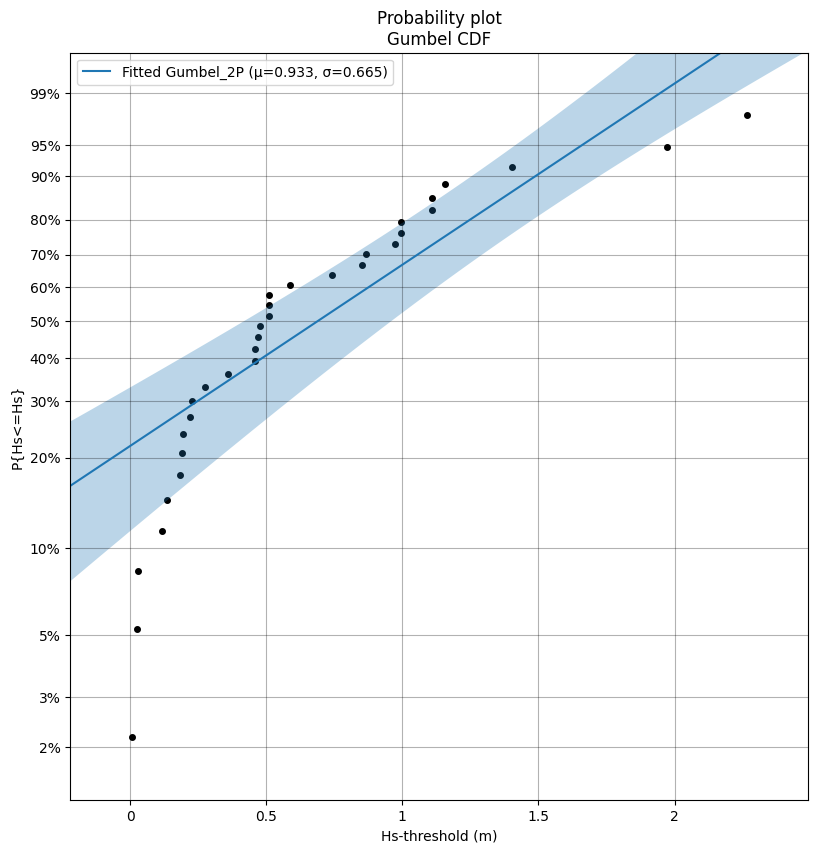

In [13]:
wag = rf.Fit_Gumbel_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

### Fit Exponential 2P

Results from Fit_Exponential_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 32/0 (0% right censored) 

Parameter  Point Estimate  Standard Error   Lower CI   Upper CI
   Lambda         1.58335        0.279899     1.1197    2.23897
 1/Lambda        0.631574        0.111647   0.446634   0.893093
    Gamma      0.00522227               0 0.00522227 0.00522227 

Goodness of fit    Value
 Log-likelihood -17.2947
           AICc  39.0032
            BIC  41.5209
             AD 0.898592 



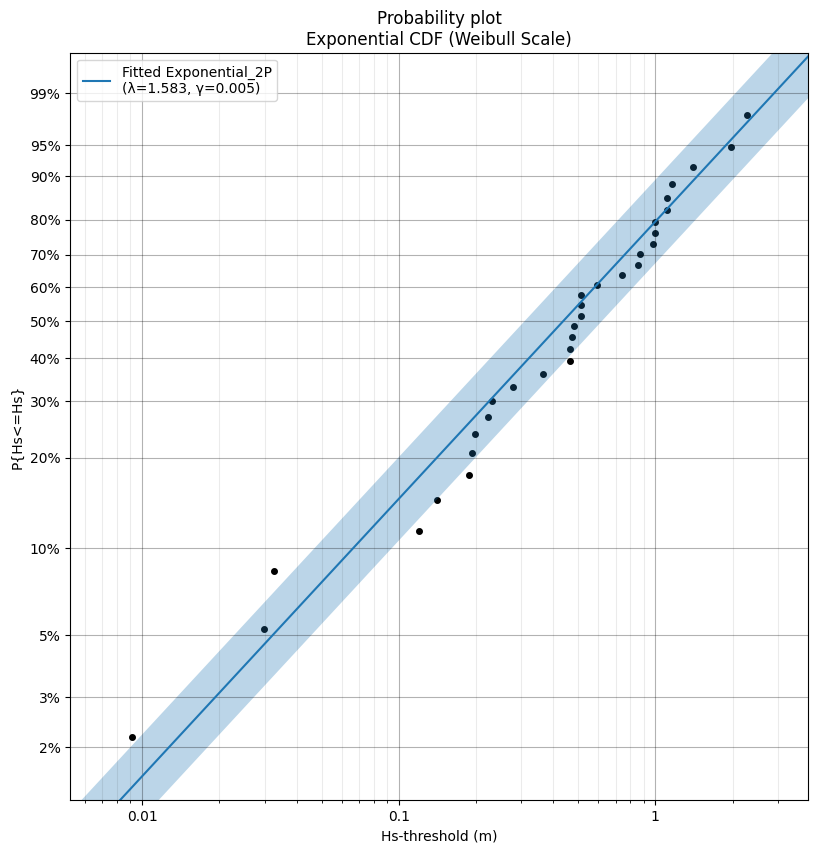

In [14]:
wae = rf.Fit_Exponential_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

## Calculation of 100 year return wave

In [15]:
#
#  Determine return period values
#
#
# define exceedance value for 100 yr return
# 
treturn = 100
numberyears = 9
numb = len(pot_maxima) / numberyears
prob = 1 - 1/(numb * treturn)
print(prob)

0.9971875


Ensure to add back the threshold tare in the estimated wave height value!

In [16]:
# Weibull 2
X_lower,X_point,X_upper = waw2.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull2P ',treturn,'Year return value is ',X_point,' (m)')

# Weibull 3
X_lower,X_point,X_upper = waw3.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull3P ',treturn,'Year return value is ',X_point,' (m)')

# Gumbel
X_lower,X_point,X_upper = wag.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Gumbel ',treturn,'Year return value is ',X_point,' (m)')

# Exponential
X_lower,X_point,X_upper = wae.distribution.CDF(CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Exponential ',treturn,'Year return value is ',X_point,' (m)')

Weibull2P  100 Year return value is  6.9634640035643685  (m)
Weibull3P  100 Year return value is  6.9634640035643685  (m)
Gumbel  100 Year return value is  5.809962258980972  (m)
Exponential  100 Year return value is  7.414884098358286  (m)


## Compare all  distributions

Results from Fit_Everything:
Analysis method: MLE
Failures / Right censored: 32/0 (0% right censored) 

   Distribution    Alpha    Beta      Gamma  Alpha 1  Beta 1 Alpha 2      Beta 2 Proportion 1 DS        Mu    Sigma  Lambda Log-likelihood    AICc     BIC       AD optimizer
     Weibull_CR                             0.663484  1.0542 2.26509 8.11073e+06                                                  -3.81953 17.1205  21.502 0.735311       TNC
 Exponential_1P                                                                                                     1.57036       -17.5582 37.2497 38.5821 0.862266       TNC
 Exponential_2P                  0.00522227                                                                         1.58335       -17.2947 39.0032 41.5209 0.898592       TNC
     Weibull_2P 0.659597  1.1073                                                                                                  -17.3133 39.0404 41.5581 0.705094       TNC
       Gamma_2P 0.575363 1

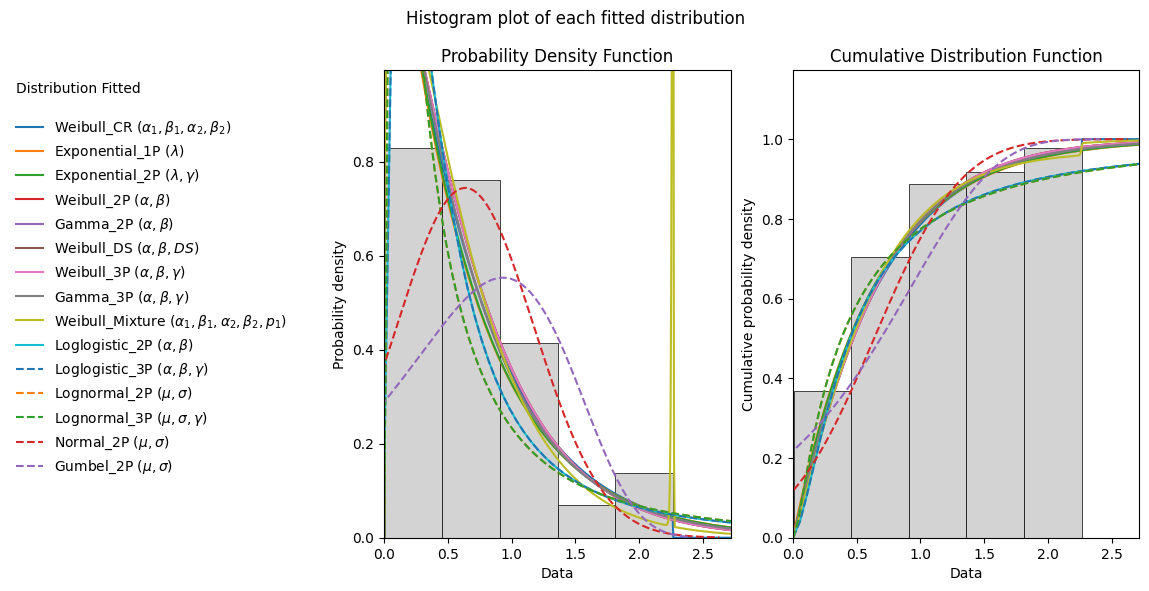

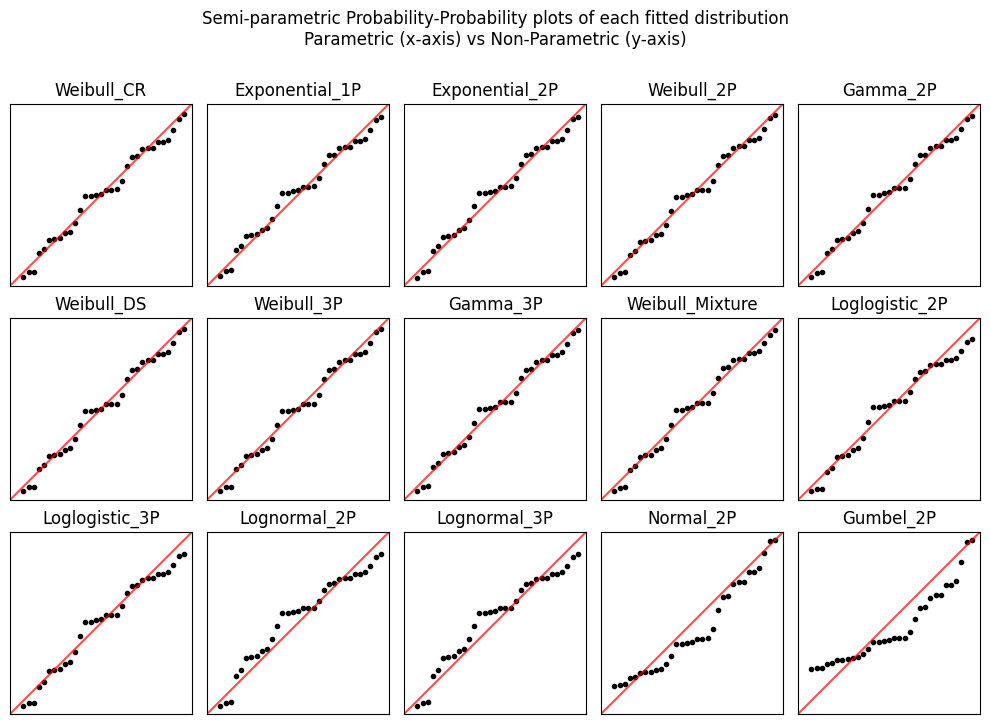

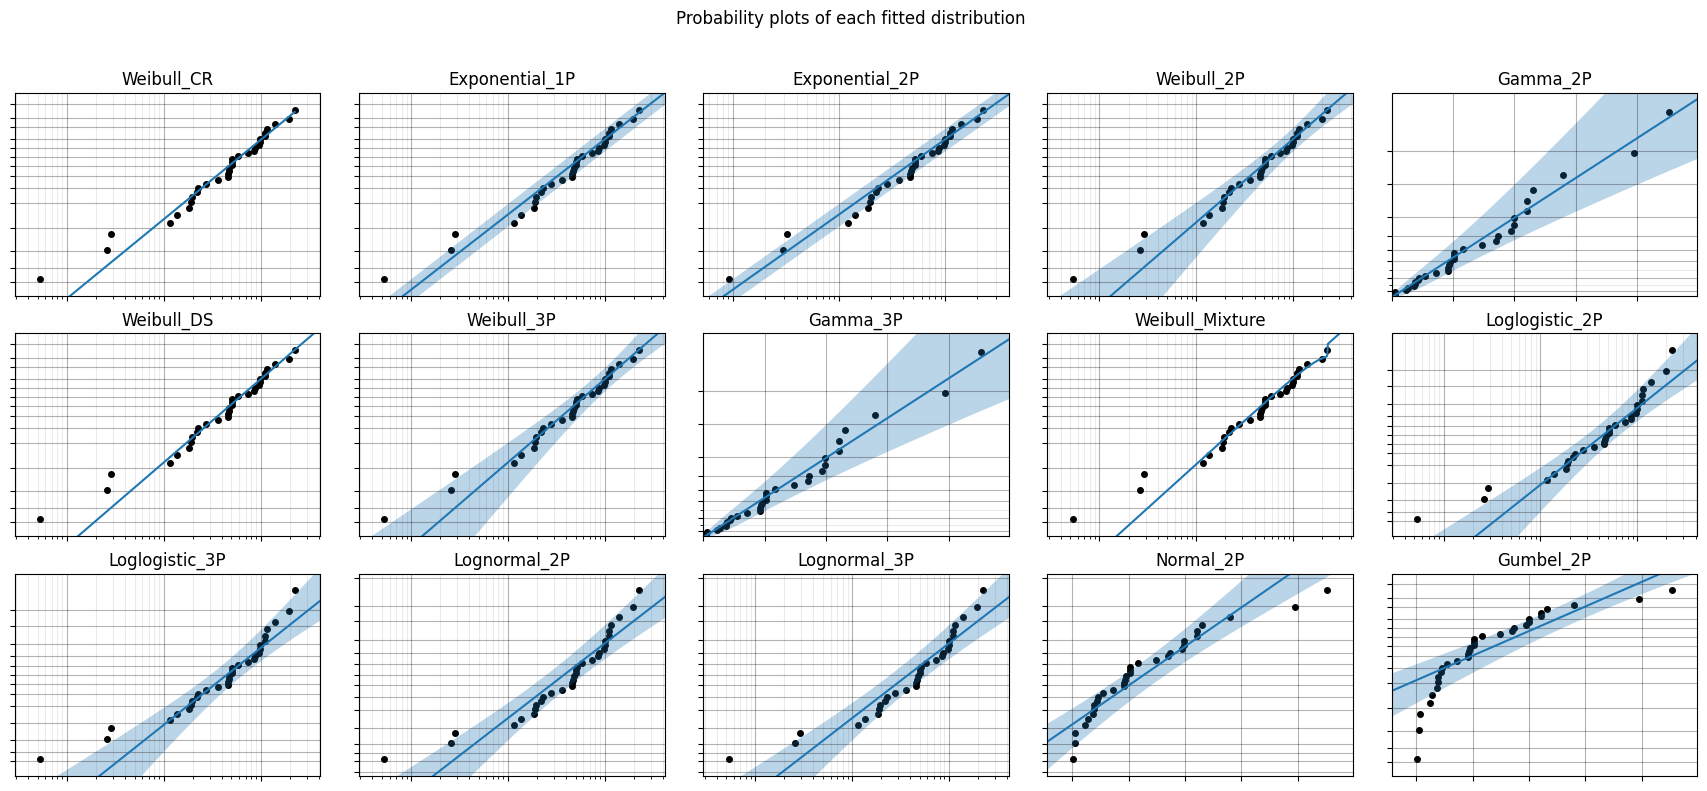

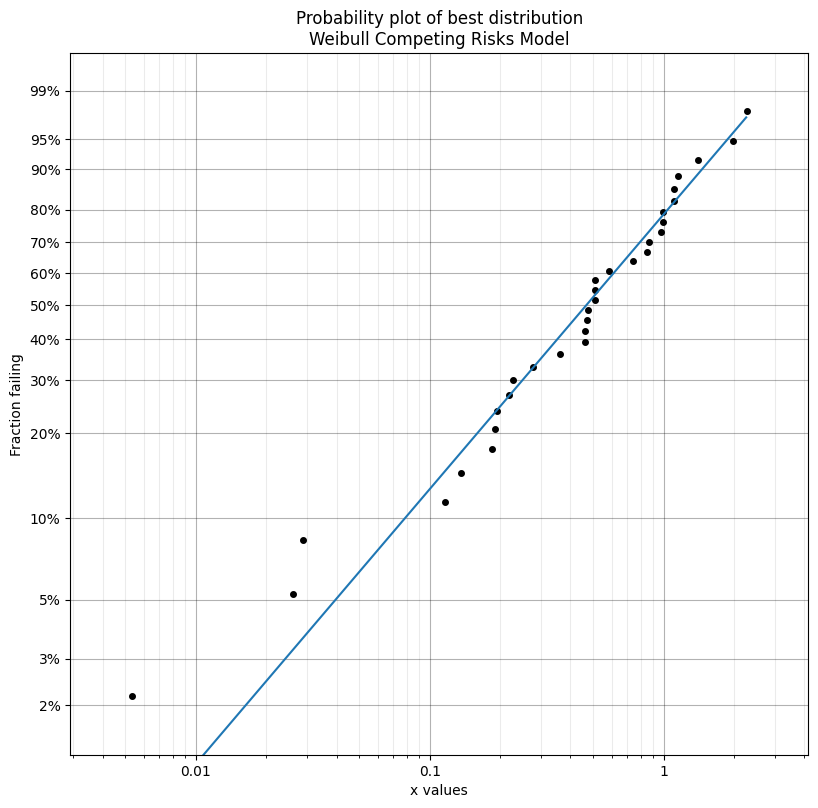

AttributeError: 'Competing_Risks_Model' object has no attribute 'parameters'

In [17]:
results = rf.Fit_Everything(failures=dfmax)  # fit all the models
print('The best fitting distribution was', results.best_distribution_name, 'which had parameters', results.best_distribution.parameters)

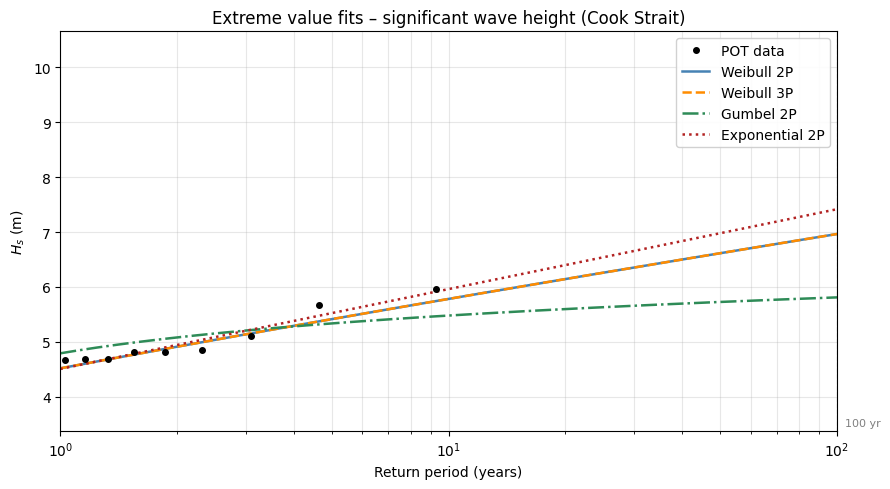

In [ ]:
#Compare the four selected distributions against empirical data

import numpy as np
import matplotlib.pyplot as plt

data_sorted = np.sort(dfmax)
n = len(data_sorted)
empirical_p = np.arange(1, n + 1) / (n + 1)

# Return period axis (years)
rp_plot = np.logspace(np.log10(1), np.log10(10000), 300)
prob_plot = np.clip(1 - 1 / (numb * rp_plot), 1e-9, 1 - 1e-9)

# Hs along return period axis for each distribution
hs_w2  = np.array([waw2.distribution.quantile(p) + tare for p in prob_plot])
hs_w3  = np.array([waw3.distribution.quantile(p) + tare for p in prob_plot])
hs_gum = np.array([wag.distribution.quantile(p)  + tare for p in prob_plot])
hs_exp = np.array([wae.distribution.quantile(p)  + tare for p in prob_plot])

rp_empirical = 1 / (numb * (1 - empirical_p))
hs_empirical = data_sorted + tare

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogx(rp_empirical, hs_empirical, 'ko', ms=4, label='POT data', zorder=5)
ax.semilogx(rp_plot, hs_w2,  '-',  color='steelblue',  lw=1.8, label='Weibull 2P')
ax.semilogx(rp_plot, hs_w3,  '--', color='darkorange',  lw=1.8, label='Weibull 3P')
ax.semilogx(rp_plot, hs_gum, '-.',  color='seagreen',   lw=1.8, label='Gumbel 2P')
ax.semilogx(rp_plot, hs_exp, ':',  color='firebrick',   lw=1.8, label='Exponential 2P')

for tr in [100]:
    ax.axvline(tr, color='grey', linewidth=0.8, linestyle='--')
    ax.text(tr * 1.05, ax.get_ylim()[0] + 0.1, f'{tr} yr', fontsize=8, color='grey')

ax.set_xlabel('Return period (years)')
ax.set_ylabel('$H_s$ (m)')
ax.set_title('Extreme value fits – significant wave height (Cook Strait)')
ax.legend(framealpha=0.9)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([1, 100])

plt.tight_layout()
plt.savefig('EVA_four_distributions.png', dpi=150, bbox_inches='tight')
plt.show()